In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END

#reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [5]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.1-8b-instant")
llm.invoke("Hey I am Rishi and I like to play cricket")

AIMessage(content="Hi Rishi, nice to meet you. Cricket is a fantastic sport, isn't it? Which role do you enjoy playing the most - batsman, bowler, or all-rounder?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 46, 'total_tokens': 87, 'completion_time': 0.06063352, 'prompt_time': 0.002137713, 'queue_time': 0.045711666, 'total_time': 0.062771233}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--aa849c0e-d838-4214-91da-ba6078dc05c4-0', usage_metadata={'input_tokens': 46, 'output_tokens': 41, 'total_tokens': 87})

### Create Nodes

In [6]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}


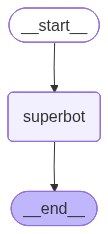

In [7]:
graph=  StateGraph(State)

#node
graph.add_node("superbot",superbot)

graph.add_edge(START, "superbot")
graph.add_edge("superbot",END)

graph_builder=graph.compile(checkpointer=memory)

#Display
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [10]:

config={"configurable":{"thread_id":"1"}}
graph_builder.invoke({"messages":"Hi, I am Rishi and I like to play cricket"},config=config)


{'messages': [HumanMessage(content='Hi, I am Rishi and I like to play cricket', additional_kwargs={}, response_metadata={}, id='2180afa5-e682-4214-923b-92a651a43912'),
  AIMessage(content="Nice to meet you, Rishi. Cricket is a fantastic sport, isn't it? There's something about the thrill of hitting a six, the strategy involved in bowling, and the camaraderie with teammates that makes it so enjoyable.\n\nAre you an avid cricketer, Rishi? Do you play for a local team, a club, or maybe even at a school level?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 47, 'total_tokens': 126, 'completion_time': 0.123650539, 'prompt_time': 0.002290258, 'queue_time': 0.045808092, 'total_time': 0.125940797}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--ac34456e-3758-4fab-861c-6ce5966b852e-0', usage_metadata={'input_tokens': 47, 'output_tok

The config line with thread_id is needed for conversation memory and state management. Here's why:

Thread ID tracks conversation state: It creates a unique identifier for this conversation thread. LangGraph uses this to store and retrieve conversation history.

Enables checkpointing: The MemorySaver() checkpointer you created saves the state of each invocation. The thread_id tells it which conversation's history to save and load.

Multiple conversations: Without it, all invocations would share the same state. With thread_id, you can have multiple independent conversations:

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

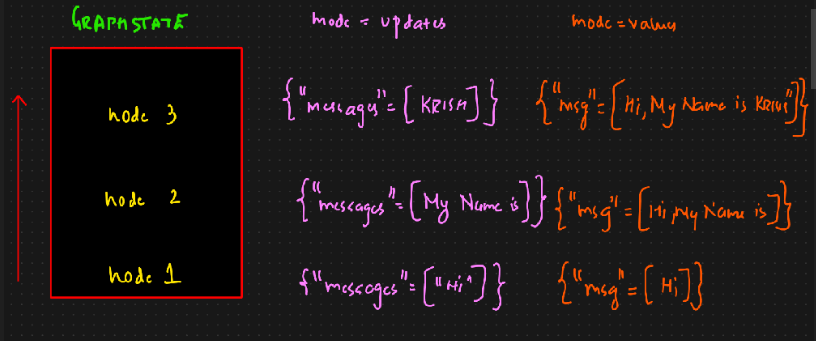

### Streaming the responses with Stream method

In [13]:
#create a thread
config={"configurable":{"thread_id":"2"}}

for chunk in graph_builder.stream({"messages":"I also like to play football"},config,stream_mode="updates"):
    print(chunk)



{'superbot': {'messages': [AIMessage(content="You're a multi-sport enthusiast, Rishi. Football and cricket are two great sports that require different skill sets, but both are exciting to play and watch. \n\nDo you play football competitively, like in a school or local league, or is it more of a recreational activity with friends? And which position do you usually play in football, if you don't mind me asking?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 220, 'total_tokens': 299, 'completion_time': 0.115909161, 'prompt_time': 0.016281439, 'queue_time': 0.046522591, 'total_time': 0.1321906}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='run--cd1248df-a89e-4892-bccb-440e3bb0823e-0', usage_metadata={'input_tokens': 220, 'output_tokens': 79, 'total_tokens': 299})]}}


In [14]:
#create a thread
config={"configurable":{"thread_id":"2"}}

for chunk in graph_builder.stream({"messages":"I love hockey as well."},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, I am Rishi and I like to play cricket', additional_kwargs={}, response_metadata={}, id='4e0ba7ae-628a-4c50-b3e1-7c10d50da38a'), AIMessage(content="Nice to meet you, Rishi. Cricket is a fantastic sport, isn't it? I'm sure you must have enjoyed watching or playing various formats of the game, from Test matches to limited-overs formats like ODIs and T20s.\n\nAre you an avid fan of a particular team or player? Do you prefer batting, bowling, or fielding? Have you ever participated in any local or school cricket tournaments? I'd love to chat with you about cricket!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 47, 'total_tokens': 143, 'completion_time': 0.154452646, 'prompt_time': 0.003231277, 'queue_time': 0.046250882, 'total_time': 0.157683923}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_1151d4f23c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Contains langgraph_node, the node emitting the event.

In [17]:
config={"configurable":{"thread_id":"3"}}

async for event in graph_builder.astream_events({"messages":"Hi, I am RiShi and I like to play cricket"},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, I am RiShi and I like to play cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': 'd5eefea9-abfa-4ade-8363-56eabf625aa8', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, I am RiShi and I like to play cricket', additional_kwargs={}, response_metadata={}, id='69eadf22-8247-4eec-8812-f0e6863c00c4')]}}, 'name': 'superbot', 'tags': ['graph:step:3'], 'run_id': 'd009c61c-c438-40e6-82fb-e0411c02b4b1', 'metadata': {'thread_id': '3', 'langgraph_step': 3, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:22a04b19-5253-3056-8080-dc80a2a0c866'}, 'parent_ids': ['d5eefea9-abfa-4ade-8363-56eabf625aa8']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi, I am RiShi and I like to play cricket', addit